# 1️⃣ Business Understanding

In [1]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
cal = fetch_california_housing(as_frame=True)
data = cal['data']
frame = cal['frame']
y = frame['MedHouseVal']

# 2️⃣ Data Understanding

To begin, predicting housing prices is very important for many different reasons. A key part of market predictions is to find the optimal time to either buy a house, rent a house, or even sell your house. With the predictions we generate, there would be many people who can benefit from it, ranging from regular people trying to buy or trying to sell things, or even other analysts trying to give market predictions for others to benefit from. The features that most influence home prices include many things, including the number of bedrooms, the age of the house, the location of the house, as well as the population of the area where the house is located. We will also find the location of the more affordable areas for buying houses within California, which in many ways would help benefit people in need of more affordable housing. To a certain degree of accuracy, we can honestly predict home value, but I’m unsure of the complete. 

In [3]:
print(data)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None


In [5]:
print(data.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [6]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   

            Latitude  Longitude  
MedInc     -0.079809  -0.015176  
HouseAge    0.011173  -0.108197  
AveRooms    0.106389  -0.027540  
AveBedrms   0.069721   0.013344  
Population -0.108785   0.099773  
AveOccup    0.002366   0.002476  
Latitude    1.000000  -0.924664  
Longitude  -0.924664   1.000000  


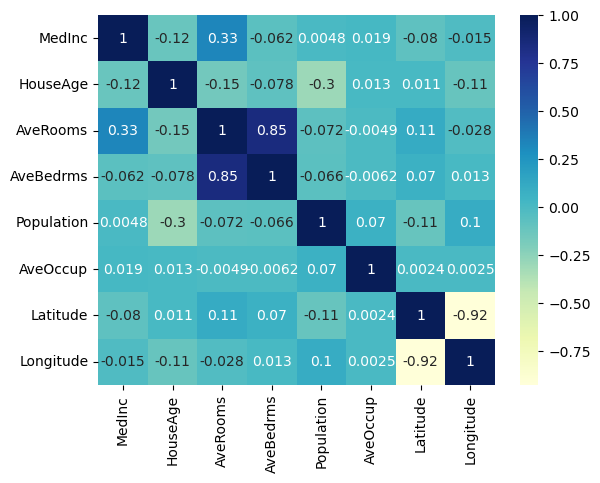

In [7]:
co_mtx = data.corr(numeric_only=True)
print(co_mtx)
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.show()

In [8]:
fig = px.scatter(data,x='MedInc', y='AveRooms', color='HouseAge', width=500, height=500)
fig.show()

In [9]:
fig = px.scatter(data,x='AveRooms', y='AveBedrms', color='MedInc', width=500, height=500)
fig.show()

In [10]:
fig = px.histogram(data, x='MedInc', nbins=40, title='Median Income Distribution')
fig.show()

The distribution of median income is skewed towards the right, indicating that most locations are low to median income, and very few are high income. Thus, this will likely have a very large factor in prediciting housing prices.

In [11]:
fig = px.box(data, y='HouseAge', title='Distribution of House Age', width=500, height=500)
fig.show()

This box plot is centered, with the quartiles relatively evenly far away from the mean, and the whiskers the same way. This indicates that house ages are relatively even across California, and as such are unlikely to affect housing prices.

In [12]:
fig = px.histogram(data, x='Population', nbins=1000, histnorm='density', title='Population Distribution (Density Plot)')
fig.show()

This histogram is extremely strongly right skewed, indicating that most people live in areas with very few people, and a few people live in areas with a lot of people. This may be an important factor in affecting housing prices.

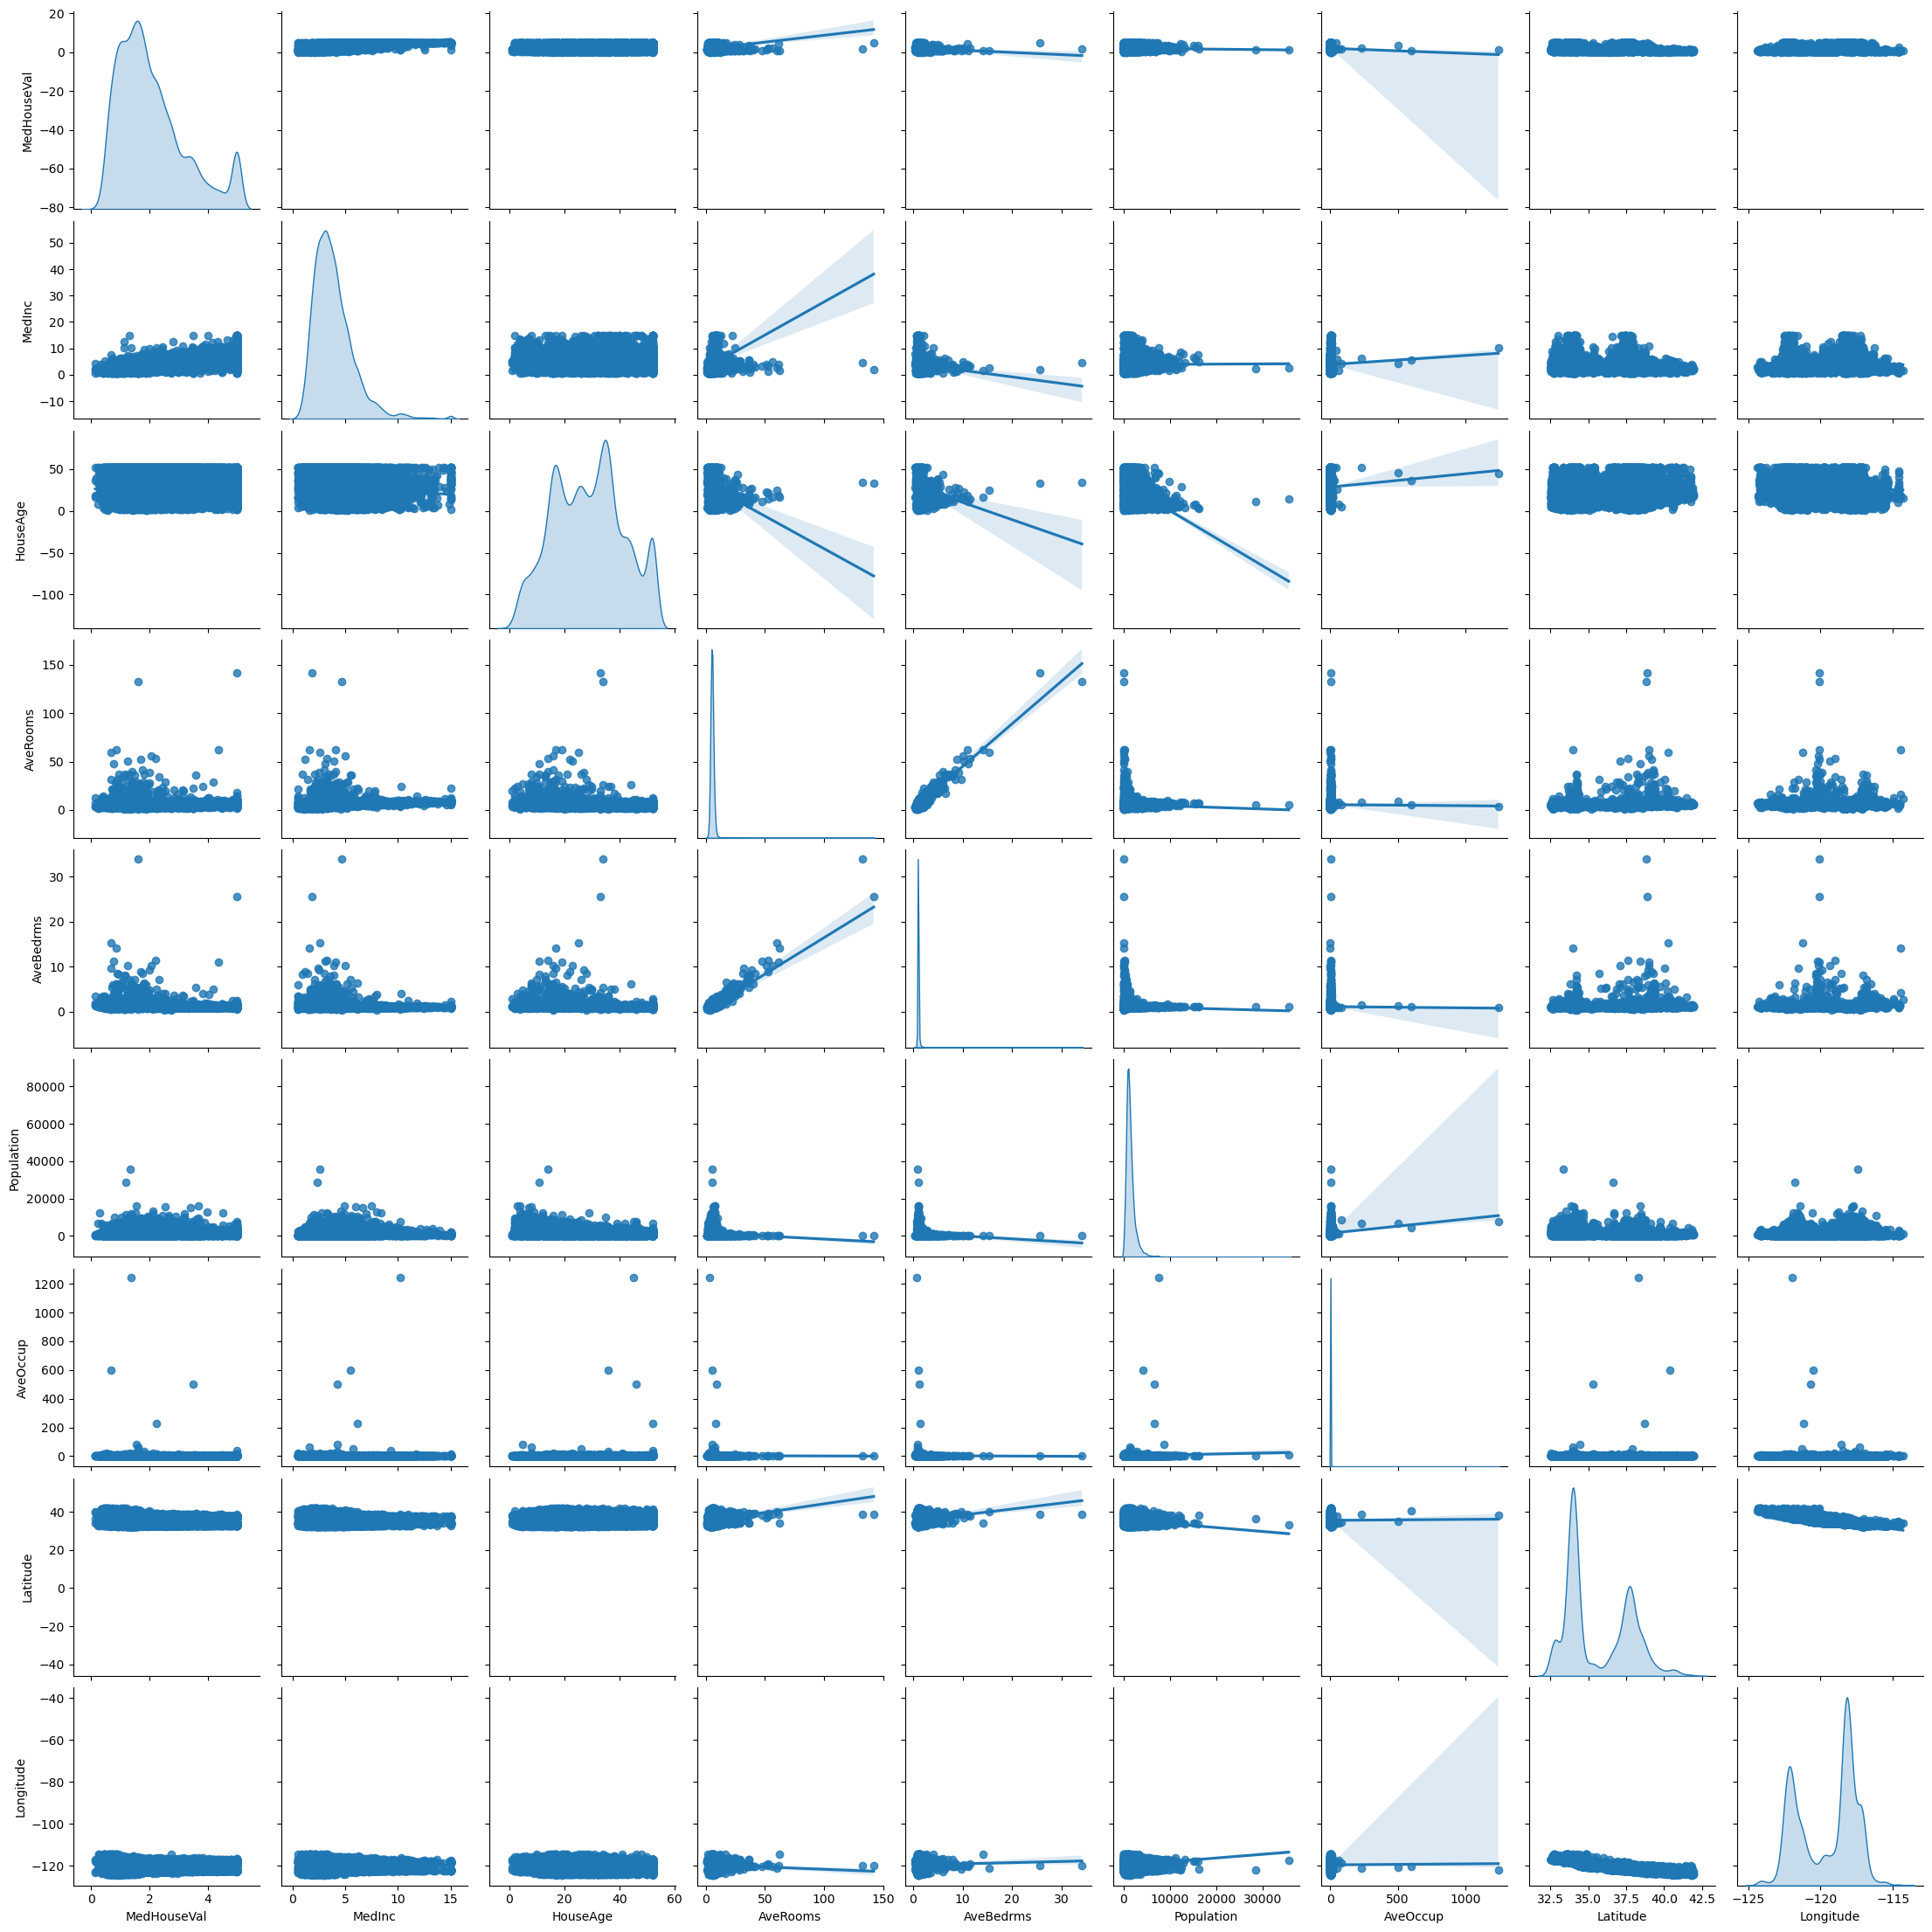

In [13]:
train_dataset = data.copy()
train_dataset.insert(0, "MedHouseVal", y)
view = sns.pairplot(train_dataset, kind="reg", diag_kind="kde")

In [14]:
fig = px.scatter(data,x='Longitude', y='Latitude', color='MedInc', width=500, height=500)
fig.show()

# 3️⃣ Data Preparation

In [16]:
data_train, data_test, y_train, y_test = train_test_split(data, y, test_size=0.4, random_state=50)

In [17]:
scaler = StandardScaler()
data_train_scaled = scaler.fit_transform(data_train)
data_test_scaled = scaler.transform(data_test)

For this data preparation phase, I split the data into it's corresponding X and y values, and created a second, Z-score scaled, version of the data, for use with the linear regression algorithm. I looked at the outliers present in the data, and decided to leave them as is, and reevaluate if they end up causing issues later down the line.

# 4️⃣ Modeling
# 1. Linear Regression

In [18]:
model = LinearRegression()

In [19]:
oooo = {"FunctionName":[], "R²":[], "MSE":[], "RMSE":[],"MedInc":[],"HouseAge":[],"AveRooms":[],"AveBedrms":[],"Population":[],"AveOccup":[],"Latitude":[],"Longitude":[]}
comparison = pd.DataFrame(oooo)

In [21]:
model.fit(data_train_scaled, y_train)

LinearRegression()

In [22]:
r2 = model.score(data_test_scaled, y_test)
print("R²:", r2)
y_pred = model.predict(data_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)



R²: 0.603513555879401
MSE: 0.5239350688107607
RMSE: 0.7238335919330912


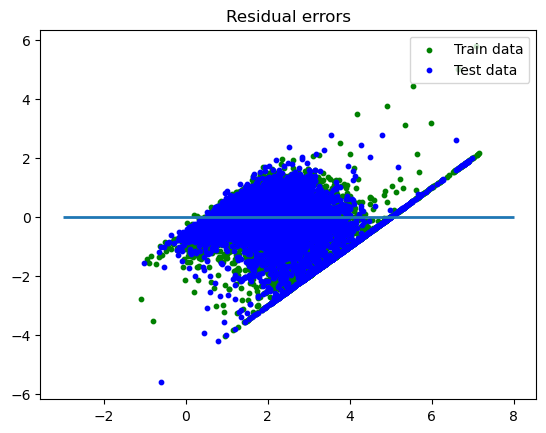

In [23]:
plt.scatter(model.predict(data_train_scaled),
            model.predict(data_train_scaled) - y_train,
            color="green", s=10,
            label='Train data')

plt.scatter(model.predict(data_test_scaled),
            model.predict(data_test_scaled) - y_test,
            color="blue", s=10,
            label='Test data')
plt.hlines(y=0, xmin=-3, xmax=8, linewidth=2)
plt.legend(loc='upper right')
plt.title("Residual errors")
plt.show()

In [24]:
a = pd.DataFrame(zip(data.columns, model.coef_))
a

,0,1
0,MedInc,0.835217
1,HouseAge,0.110863
2,AveRooms,-0.263511
3,AveBedrms,0.284469
4,Population,-0.009978
5,AveOccup,-0.046550
6,Latitude,-0.888504
7,Longitude,-0.858328


In [25]:
print(model.intercept_)

2.072405029877266


In [26]:
newRow = {"FunctionName":["Linear Regression"], "R²":[r2], "MSE":[mse], "RMSE":[rmse],"MedInc":[a[1].loc[a.index[0]]],"HouseAge":[a[1].loc[a.index[1]]],"AveRooms":[a[1].loc[a.index[2]]],"AveBedrms":[a[1].loc[a.index[3]]],"Population":[a[1].loc[a.index[4]]],"AveOccup":[a[1].loc[a.index[5]]],"Latitude":[a[1].loc[a.index[6]]],"Longitude":[a[1].loc[a.index[7]]]}
comparison = pd.concat([comparison, pd.DataFrame(newRow)], ignore_index=True)

# 2. Decision Tree Regressor

In [27]:
dt_default = DecisionTreeRegressor(random_state=50)
dt_default.fit(data_train, y_train)

DecisionTreeRegressor(random_state=50)

In [28]:
r2 = dt_default.score(data_test, y_test)
print("R²:", r2)
y_pred = dt_default.predict(data_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)


R²: 0.5753649211722337
MSE: 0.56113194421703
RMSE: 0.7490874075947547


In [29]:
importances = dt_default.feature_importances_
pd.DataFrame(importances, data.columns)

,0
MedInc,0.530267
HouseAge,0.055928
AveRooms,0.050131
AveBedrms,0.025717
Population,0.033732
AveOccup,0.133839
Latitude,0.090064
Longitude,0.080321


In [30]:
newRow = {"FunctionName":["dt_default"], "R²":[r2], "MSE":[mse], "RMSE":[rmse],"MedInc":[importances[0]],"HouseAge":[importances[1]],"AveRooms":[importances[2]],"AveBedrms":[importances[3]],"Population":[importances[4]],"AveOccup":[importances[5]],"Latitude":[importances[6]],"Longitude":[importances[7]]}
comparison = pd.concat([comparison, pd.DataFrame(newRow)], ignore_index=True)

In [31]:
dt_tuned = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=40,
    min_samples_leaf=10
)
dt_tuned.fit(data_train, y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, min_samples_split=40)

In [32]:
r2 = dt_tuned.score(data_test, y_test)
print("R²:", r2)
y_pred = dt_tuned.predict(data_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)


R²: 0.6626580597306034
MSE: 0.44577885400299166
RMSE: 0.6676667237499497


In [33]:
importances = dt_tuned.feature_importances_
pd.DataFrame(importances, data.columns)

,0
MedInc,0.679364
HouseAge,0.042807
AveRooms,0.032486
AveBedrms,0.004027
Population,0.005864
AveOccup,0.141880
Latitude,0.049908
Longitude,0.043663


In [34]:
newRow = {"FunctionName":["dt_tuned"], "R²":[r2], "MSE":[mse], "RMSE":[rmse],"MedInc":[importances[0]],"HouseAge":[importances[1]],"AveRooms":[importances[2]],"AveBedrms":[importances[3]],"Population":[importances[4]],"AveOccup":[importances[5]],"Latitude":[importances[6]],"Longitude":[importances[7]]}
comparison = pd.concat([comparison, pd.DataFrame(newRow)], ignore_index=True)

# Model 3 — Random Forest Regressor

In [35]:
rf_default = RandomForestRegressor(random_state=50)
rf_default.fit(data_train, y_train)

RandomForestRegressor(random_state=50)

In [ ]:
r2 = rf_default.score(data_test, y_test)
print("R²:", r2)
y_pred = rf_default.predict(data_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

R²: 0.7932233987807353
MSE: 0.44577885400299166
RMSE: 0.6676667237499497


In [37]:
importances = rf_default.feature_importances_
pd.DataFrame(importances, data.columns)

,0
MedInc,0.529304
HouseAge,0.055093
AveRooms,0.044590
AveBedrms,0.028535
Population,0.032453
AveOccup,0.137060
Latitude,0.087037
Longitude,0.085929


In [38]:
newRow = {"FunctionName":["rf_default"], "R²":[r2], "MSE":[mse], "RMSE":[rmse],"MedInc":[importances[0]],"HouseAge":[importances[1]],"AveRooms":[importances[2]],"AveBedrms":[importances[3]],"Population":[importances[4]],"AveOccup":[importances[5]],"Latitude":[importances[6]],"Longitude":[importances[7]]}
comparison = pd.concat([comparison, pd.DataFrame(newRow)], ignore_index=True)

In [39]:
rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=30,
    max_features='log2', 
    random_state=50)
rf_tuned.fit(data_train, y_train)

RandomForestRegressor(max_depth=30, max_features='log2', n_estimators=300,
                      random_state=50)

In [ ]:
r2 = rf_tuned.score(data_test, y_test)
print("R²:", r2)
y_pred = rf_tuned.predict(data_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

R²: 0.8065872117358173
MSE: 0.44577885400299166
RMSE: 0.6676667237499497


In [41]:
importances = rf_tuned.feature_importances_
pd.DataFrame(importances, data.columns)

,0
MedInc,0.391437
HouseAge,0.054953
AveRooms,0.111633
AveBedrms,0.038882
Population,0.032154
AveOccup,0.130149
Latitude,0.122954
Longitude,0.117837


In [ ]:
newRow = {"FunctionName":["rf_tuned"], "R²":[r2], "MSE":[mse], "RMSE":[rmse],"MedInc":[importances[0]],"HouseAge":[importances[1]],"AveRooms":[importances[2]],"AveBedrms":[importances[3]],"Population":[importances[4]],"AveOccup":[importances[5]],"Latitude":[importances[6]],"Longitude":[importances[7]]}
comparison = pd.concat([comparison, pd.DataFrame(newRow)], ignore_index=True)

In [43]:
comparison

,FunctionName,R²,MSE,RMSE,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,Linear Regression,0.603514,0.523935,0.723834,0.835217,0.110863,-0.263511,0.284469,-0.009978,-0.046550,-0.888504,-0.858328
1,dt_default,0.575365,0.561132,0.749087,0.530267,0.055928,0.050131,0.025717,0.033732,0.133839,0.090064,0.080321
2,dt_tuned,0.662658,0.445779,0.667667,0.679364,0.042807,0.032486,0.004027,0.005864,0.141880,0.049908,0.043663
3,rf_default,0.793223,0.445779,0.667667,0.529304,0.055093,0.044590,0.028535,0.032453,0.137060,0.087037,0.085929
4,rf_default,0.806587,0.445779,0.667667,0.391437,0.054953,0.111633,0.038882,0.032154,0.130149,0.122954,0.117837


# Evaluation & Insights
The model that performed the best was the Random Forest Regressor, when it was tuned. This is because Random Forest models are the best for these tasks, being equivalent to the averaged values across multiple subsets of the data. Tuning made a much bigger difference for the Decision Tree model than the Random Forest model, because the Random Forest model is so much closer to being optimized already that there is diminishing returns.

The most important feature turned out to be the Median Income, with the second most important feature being the Average number of People in each house. The third most important factor was the Average number of Rooms. Home Prices were higher along the coast, especially in the San Fransisco Bay Area and the Greater Los Angeles Metropolitan Area, as shown in the diagram below.

While our data model performed very well, there is only a level to which it can be accurate. It still is not perfect at data analysis, and could be more optimal.

In [44]:
fig = px.scatter(train_dataset,x='Longitude', y='Latitude', color='MedHouseVal', width=500, height=500)
fig.show()

# Affordability Advisor

In [78]:
print("Enter your Annual income:")
yr_income = int(input())

print("Enter your Down payment:")
down_payment = int(input())

max_monthly_payment = 0.30 * (yr_income / 12)
loan_amount = max_monthly_payment * 200
home_budget = loan_amount + down_payment

print(home_budget)

finalpred = rf_tuned.predict(data)

finalpred

affordable = np.array(True)
affordable2 = (finalpred <= home_budget)

np.info(affordable)

e = [True]

np.append(affordable, affordable2)

np.info(affordable)


print(affordable)

train_dataset.insert(0, "Afforable", affordable)

train_dataset


Enter your Annual income:
Enter your Down payment:
2504999.9999999995
class:  ndarray
shape:  ()
strides:  ()
itemsize:  1
aligned:  True
contiguous:  True
fortran:  True
data pointer: 0x125aac66930
byteorder:  little
byteswap:  False
type: bool
class:  ndarray
shape:  ()
strides:  ()
itemsize:  1
aligned:  True
contiguous:  True
fortran:  True
data pointer: 0x125aac66930
byteorder:  little
byteswap:  False
type: bool
True


,Afforable,MedHouseVal,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Affordable
0,True,4.526,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,1.0
1,True,3.585,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.0
2,True,3.521,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,NaN
3,True,3.413,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,NaN
4,True,3.422,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,NaN
...,...,...,...,...,...,...,...,...,...,...,...
20636,True,0.771,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,NaN
20637,True,0.923,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,NaN
20638,True,0.847,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,NaN
20639,True,0.894,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,NaN
